In [ ]:
# Step 0: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set(style='whitegrid')

In [ ]:
# Step 1: Load the dataset
df = pd.read_csv('imdb_top_1000.csv')

df.head(10)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762"
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,1993,A,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818"
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195"
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102"


In [3]:
df.shape  # Rows x Columns

(1000, 16)

In [4]:
df.head(10)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762"
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,1993,A,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818"
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195"
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102"


In [5]:
# Step 3: Basic structure
print('Number of rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

Number of rows and columns: (1000, 16)

Column names:
['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


In [6]:
# Step 4: Data types and missing values
print('--- DataFrame info ---')
print(df.info())

--- DataFrame info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB
None


In [7]:
print('\n--- Missing values per column ---')
print(df.isnull().sum())



--- Missing values per column ---
Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [8]:
# Peek at unique values for key categorical columns
print('Certificate unique values:')
print(df['Certificate'].value_counts())


Certificate unique values:
Certificate
U           234
A           197
UA          175
R           146
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
TV-14         1
16            1
TV-MA         1
Unrated       1
U/A           1
Name: count, dtype: int64


In [9]:
# Peek at value counts for all columns
for col in df.columns:
    print(f'\n=== {col} ===')
    print(df[col].value_counts().head(10))


=== Poster_Link ===
Poster_Link
https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNhMC00ZDIzLWFmNTEtODM1ZmRlYWMwMWFmXkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_UX67_CR0,0,67,98_AL_.jpg                    1
https://m.media-amazon.com/images/M/MV5BMjI5NjEzMDYyMl5BMl5BanBnXkFtZTgwNjgwNTg4NjE@._V1_UY98_CR3,0,67,98_AL_.jpg                                                    1
https://m.media-amazon.com/images/M/MV5BY2EyZDlhNjItODYzNi00Mzc3LWJjOWUtMTViODU5MTExZWMyL2ltYWdlXkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_UX67_CR0,0,67,98_AL_.jpg            1
https://m.media-amazon.com/images/M/MV5BODRkYzA4MGItODE2MC00ZjkwLWI2NDEtYzU1NzFiZGU1YzA0XkEyXkFqcGdeQXVyNTAyODkwOQ@@._V1_UX67_CR0,0,67,98_AL_.jpg                    1
https://m.media-amazon.com/images/M/MV5BODllYjM1ODItYjBmOC00MzkwLWJmM2YtMjMyZDU3MGJhNjc4L2ltYWdlL2ltYWdlXkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_UX67_CR0,0,67,98_AL_.jpg    1
https://m.media-amazon.com/images/M/MV5BNDYwOThlMDAtYWUwMS00MjY5LTliMGUtZWFiYTA5MjYwZDAyXkEyXkFqcGdeQXVyNjY1NTQ0NDg@._V1_UX67_CR0,0,

In [ ]:
# Step 5: Drop irrelevant columns and clean strings
df_clean = df.copy()

# Drop columns not useful for ML modeling
df_clean.drop(columns=['Poster_Link', 'Overview', 'Series_Title'], inplace=True)

# Strip whitespace from all object columns
obj_cols = df_clean.select_dtypes(include=['object']).columns
for col in obj_cols:
    df_clean[col] = df_clean[col].str.strip()

print('Remaining columns:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Remaining columns: ['Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']
Shape: (1000, 13)


In [ ]:
# Step 6: Fix data types

# Runtime: strip ' min' and convert to integer
df_clean['Runtime'] = df_clean['Runtime'].str.replace(' min', '', regex=False).str.strip()
df_clean['Runtime'] = pd.to_numeric(df_clean['Runtime'], errors='coerce')

# Released_Year: coerce any non-numeric entries (like 'PG') to NaN
df_clean['Released_Year'] = pd.to_numeric(df_clean['Released_Year'], errors='coerce')

# Gross: remove commas, then convert to float
df_clean['Gross'] = df_clean['Gross'].str.replace(',', '', regex=False)
df_clean['Gross'] = pd.to_numeric(df_clean['Gross'], errors='coerce')

print('Updated dtypes:')
print(df_clean[['Runtime', 'Released_Year', 'Gross']].dtypes)
print()
print(df_clean[['Runtime', 'Released_Year', 'Gross']].head(5))


Updated dtypes:
Runtime            int64
Released_Year    float64
Gross            float64
dtype: object

   Runtime  Released_Year        Gross
0      142         1994.0   28341469.0
1      175         1972.0  134966411.0
2      152         2008.0  534858444.0
3      202         1974.0   57300000.0
4       96         1957.0    4360000.0


In [ ]:
# Step 7: Extract primary genre
df_clean['Primary_Genre'] = df_clean['Genre'].str.split(',').str[0].str.strip()

print('Primary Genre distribution (top 15):')
print(df_clean['Primary_Genre'].value_counts().head(15))

Primary Genre distribution (top 15):
Primary_Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64


In [ ]:
# Step 8: Check and drop duplicate rows
num_duplicates = df_clean.duplicated().sum()
print('Number of duplicate rows:', num_duplicates)

if num_duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print('Duplicates dropped. New shape:', df_clean.shape)
else:
    print('No duplicate rows found.')


Number of duplicate rows: 0
No duplicate rows found.


In [14]:
# Step 9: Descriptive statistics
print('--- Numeric columns summary ---')
df_clean.describe()

--- Numeric columns summary ---


,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,999.000000,1000.000000,1000.000000,843.000000,1.000000e+03,8.310000e+02
mean,1991.217217,122.891000,7.949300,77.971530,2.736929e+05,6.803475e+07
std,23.297025,28.093671,0.275491,12.376099,3.273727e+05,1.097500e+08
min,1920.000000,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,1976.000000,103.000000,7.700000,70.000000,5.552625e+04,3.253559e+06
50%,1999.000000,119.000000,7.900000,79.000000,1.385485e+05,2.353089e+07
75%,2009.000000,137.000000,8.100000,87.000000,3.741612e+05,8.075089e+07
max,2020.000000,321.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


In [15]:
print('\n--- Categorical columns summary ---')
df_clean.select_dtypes(include=['object']).describe()



--- Categorical columns summary ---


,Certificate,Genre,Director,Star1,Star2,Star3,Star4,Primary_Genre
count,899,1000,1000,1000,1000,1000,1000,1000
unique,16,202,548,660,841,891,939,14
top,U,Drama,Alfred Hitchcock,Tom Hanks,Emma Watson,Rupert Grint,Michael Caine,Drama
freq,234,85,14,12,7,5,4,289


IMDB_Rating statistics:
count    1000.000000
mean        7.949300
std         0.275491
min         7.600000
25%         7.700000
50%         7.900000
75%         8.100000
max         9.300000
Name: IMDB_Rating, dtype: float64

Skewness: 1.017


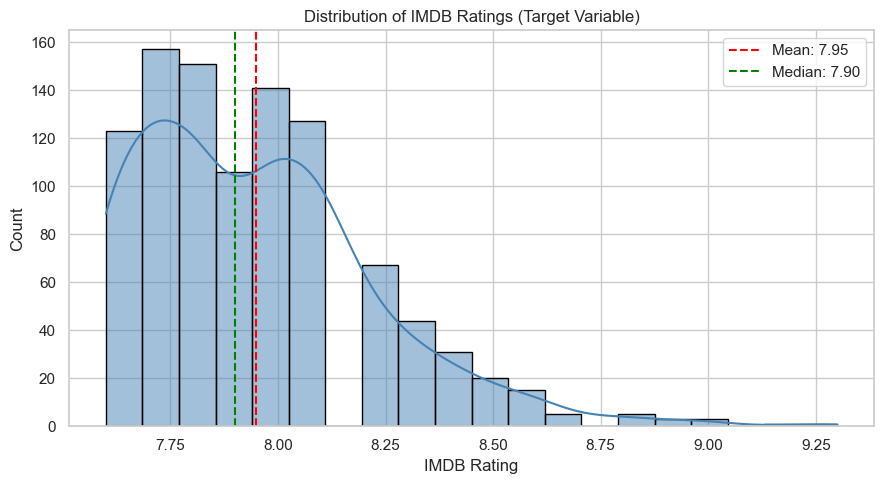

In [16]:
# Step 10: Target variable distribution
print('IMDB_Rating statistics:')
print(df_clean['IMDB_Rating'].describe())
print('\nSkewness:', round(df_clean['IMDB_Rating'].skew(), 4))

plt.figure(figsize=(9, 5))
sns.histplot(df_clean['IMDB_Rating'], bins=20, kde=True, color='steelblue', edgecolor='black')
plt.axvline(df_clean['IMDB_Rating'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['IMDB_Rating'].mean():.2f}")
plt.axvline(df_clean['IMDB_Rating'].median(), color='green', linestyle='--', label=f"Median: {df_clean['IMDB_Rating'].median():.2f}")
plt.title('Distribution of IMDB Ratings (Target Variable)')
plt.xlabel('IMDB Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


Numeric columns: ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']


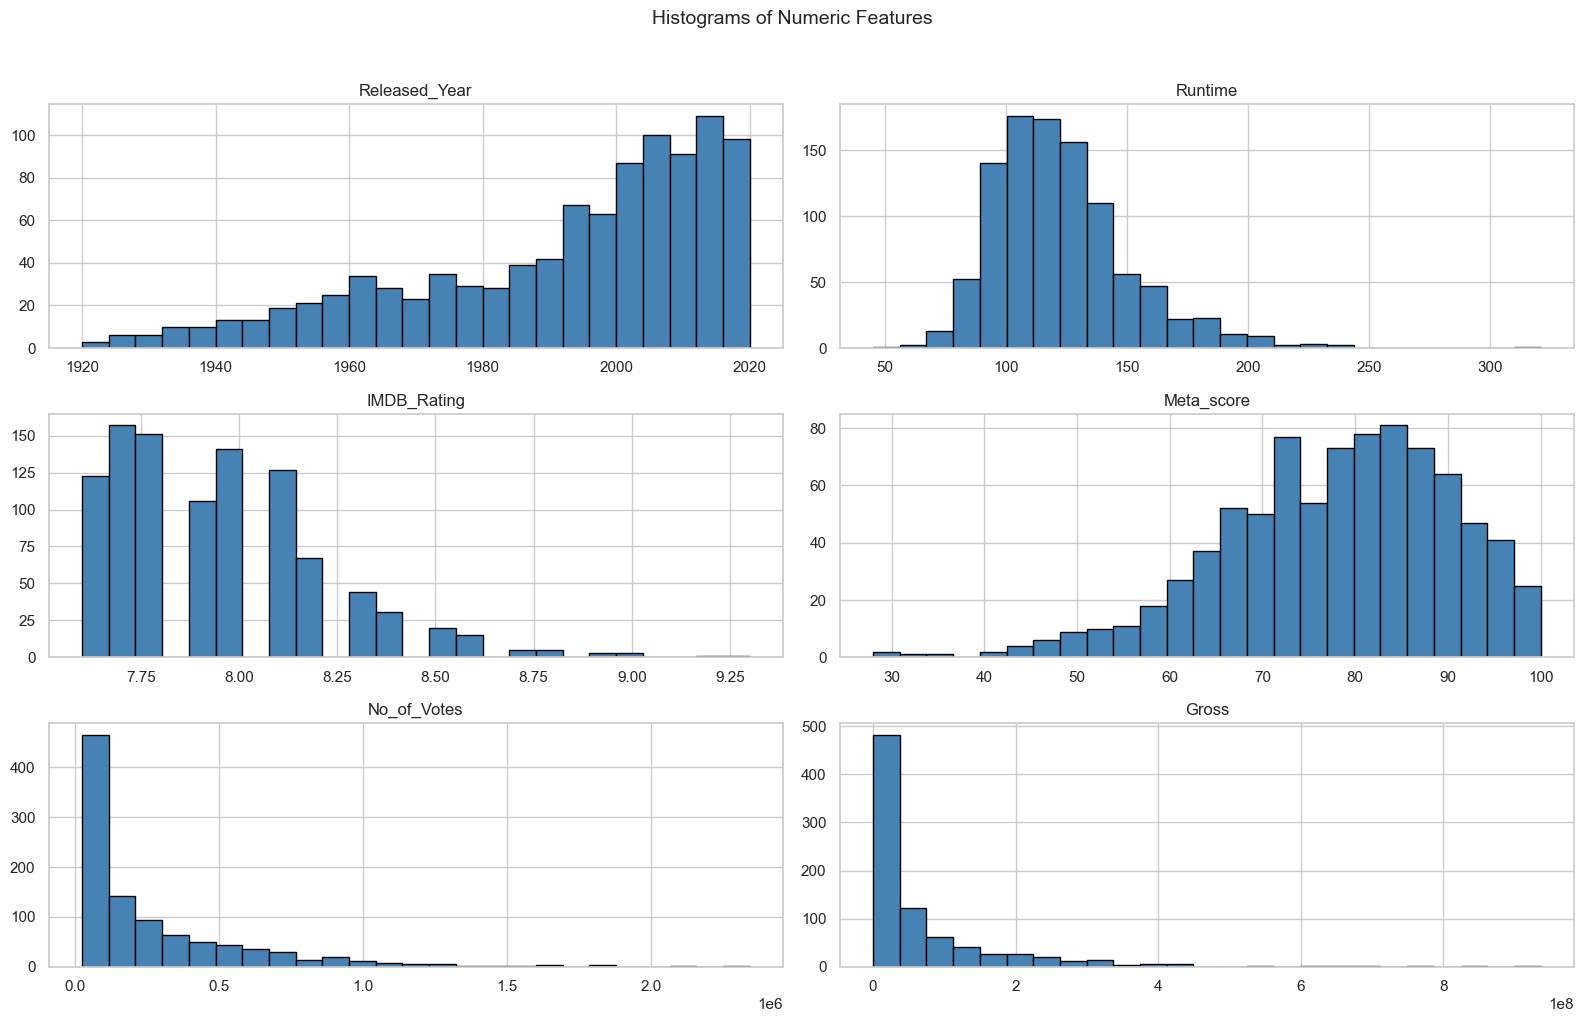

In [17]:
# Step 11: Histograms for numeric features
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)

df_clean[numeric_cols].hist(figsize=(16, 10), bins=25, color='steelblue', edgecolor='black')
plt.suptitle('Histograms of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Categorical columns: ['Certificate', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'Primary_Genre']


C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


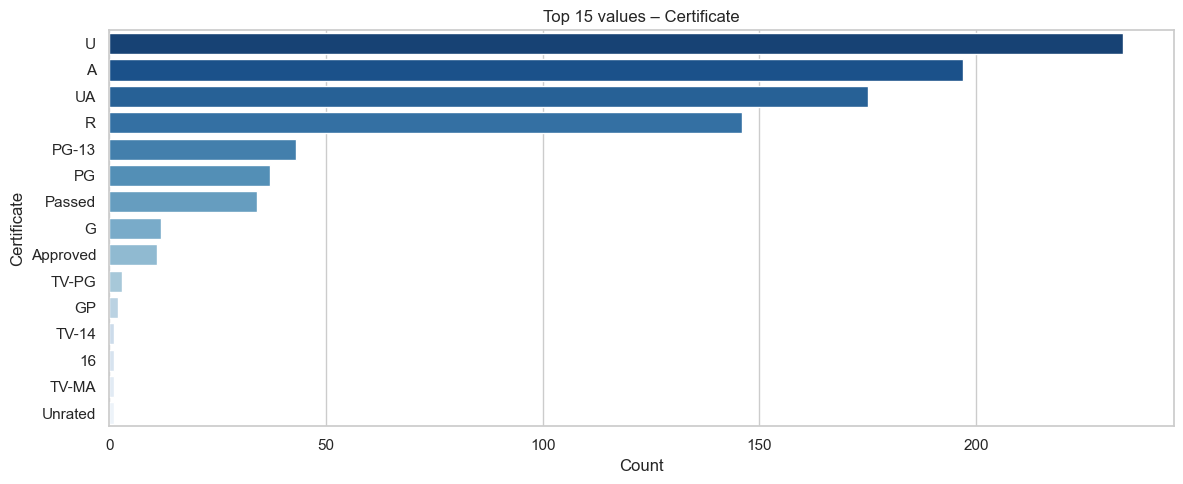

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


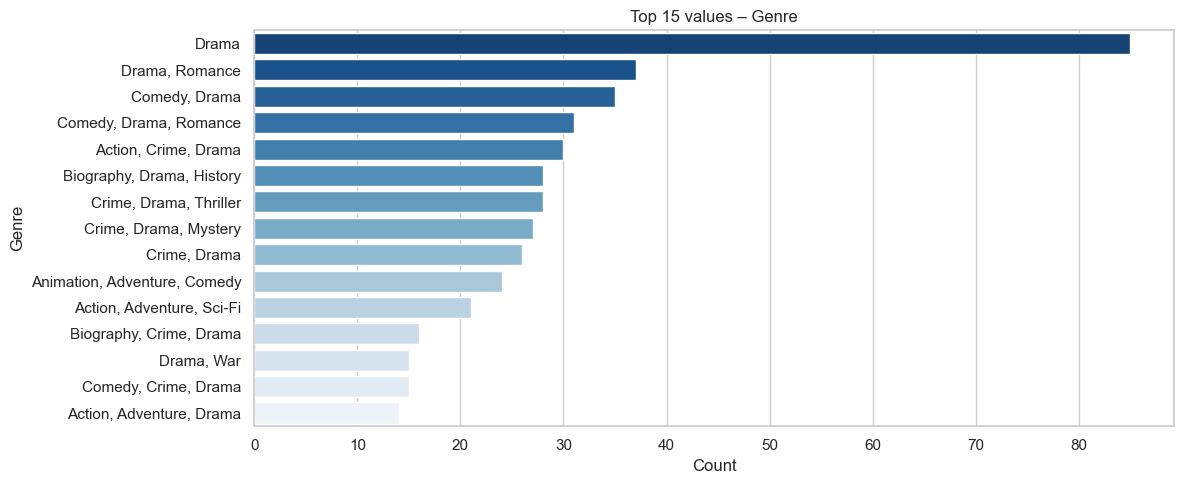

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


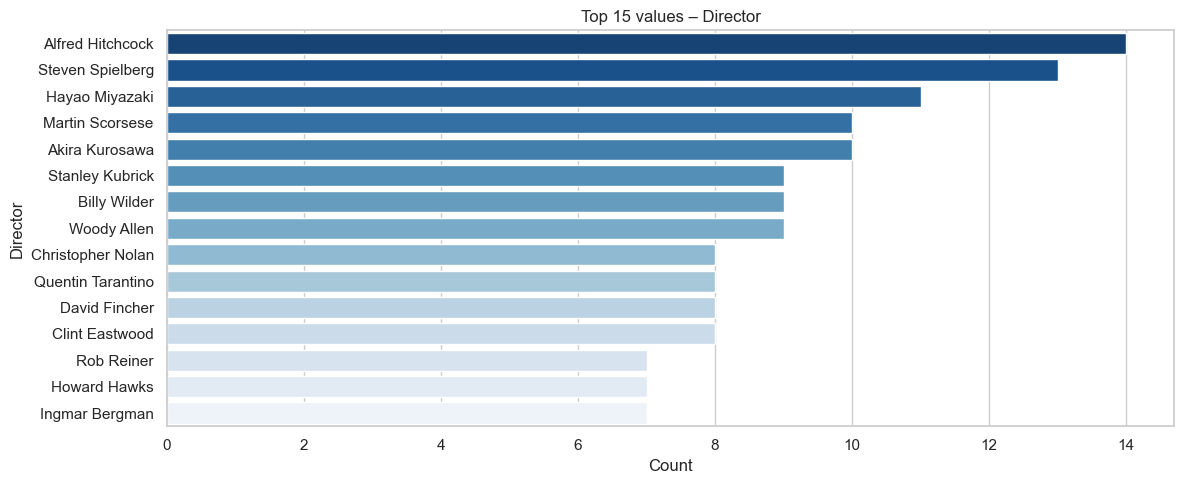

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


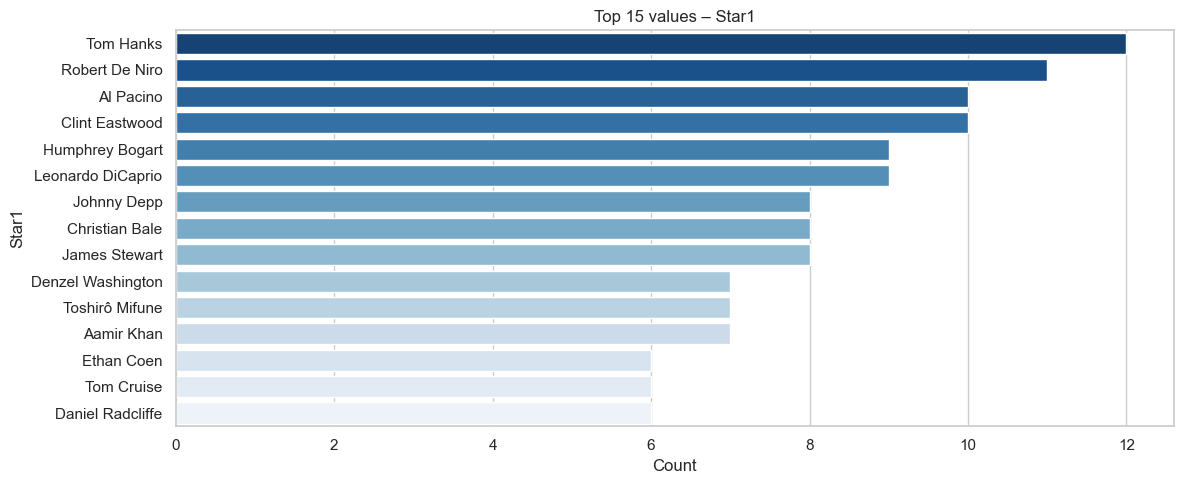

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


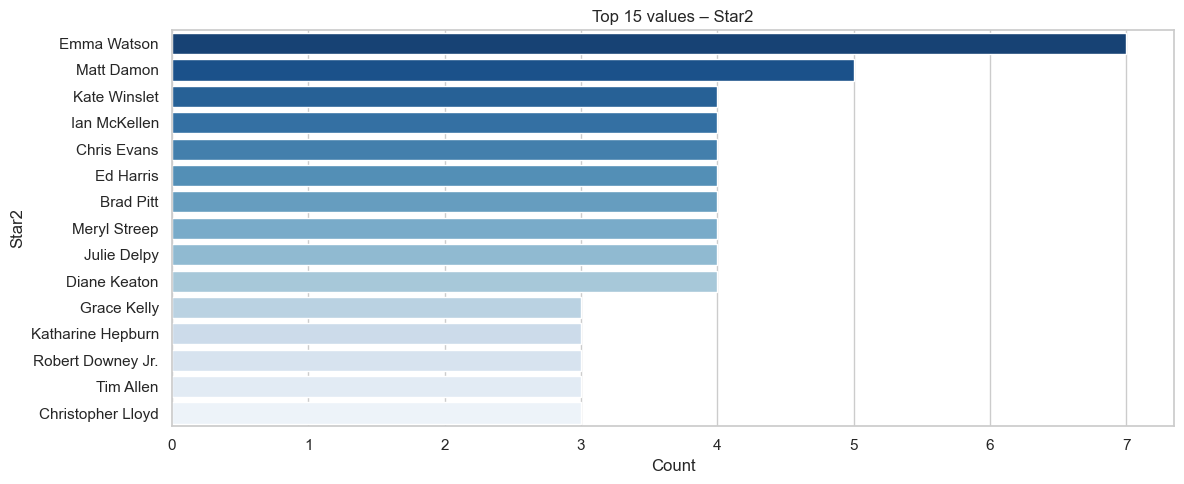

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


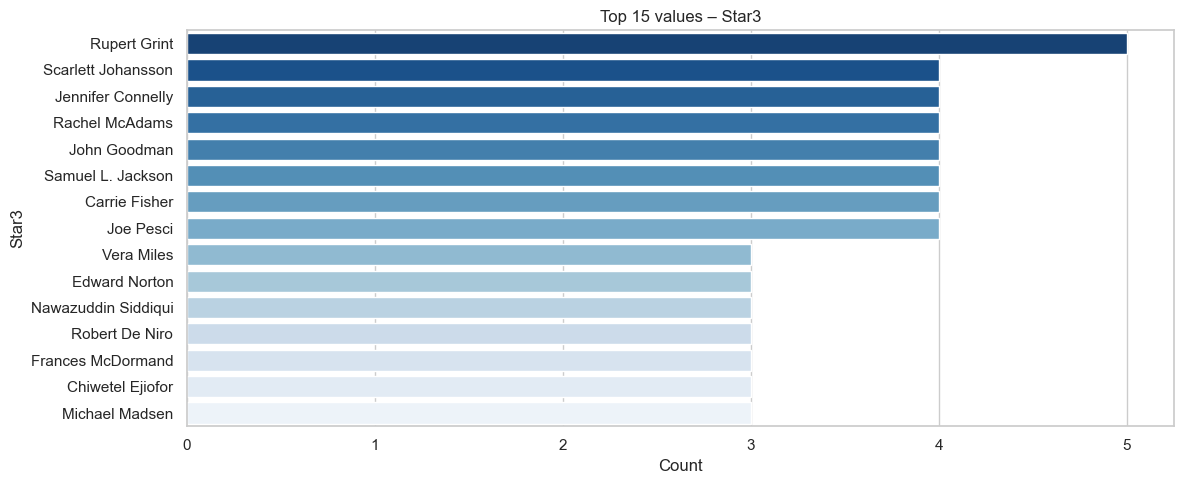

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


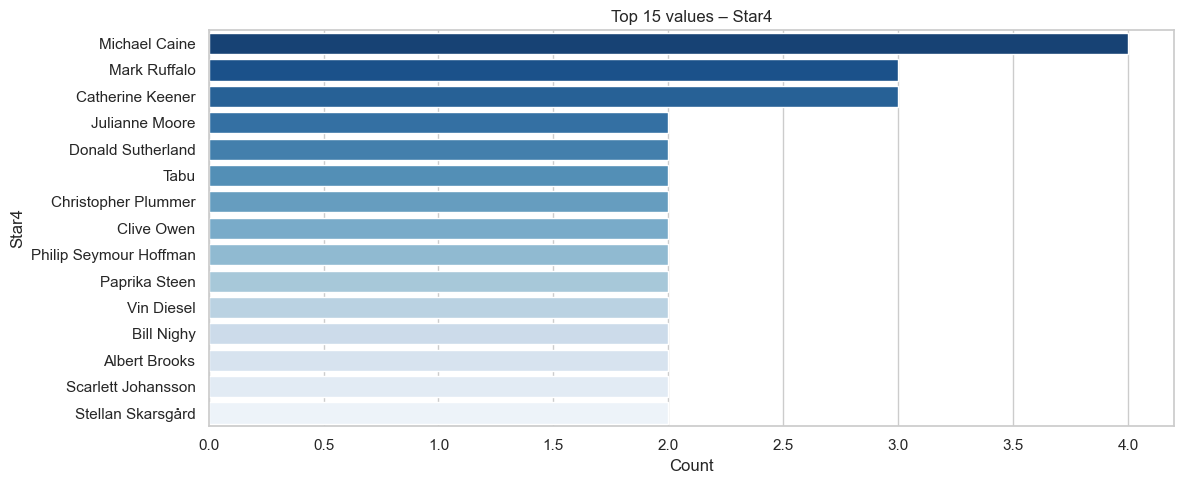

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\1131539354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')


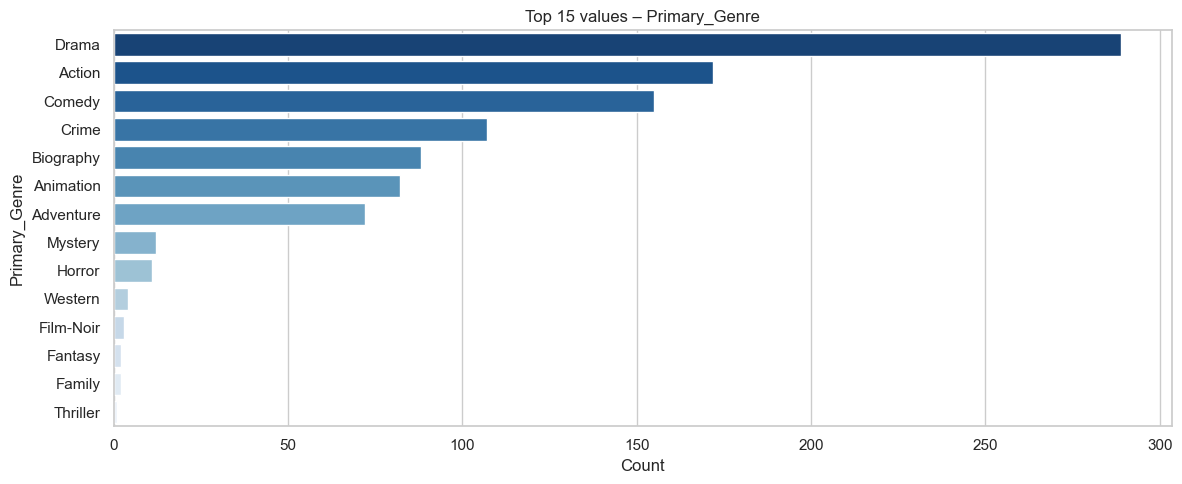

In [18]:
# Step 12: Bar charts for categorical features
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', categorical_cols)

for col in categorical_cols:
    top_vals = df_clean[col].value_counts().head(15)
    plt.figure(figsize=(12, 5))
    sns.barplot(x=top_vals.values, y=top_vals.index, palette='Blues_r')
    plt.title(f'Top 15 values – {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


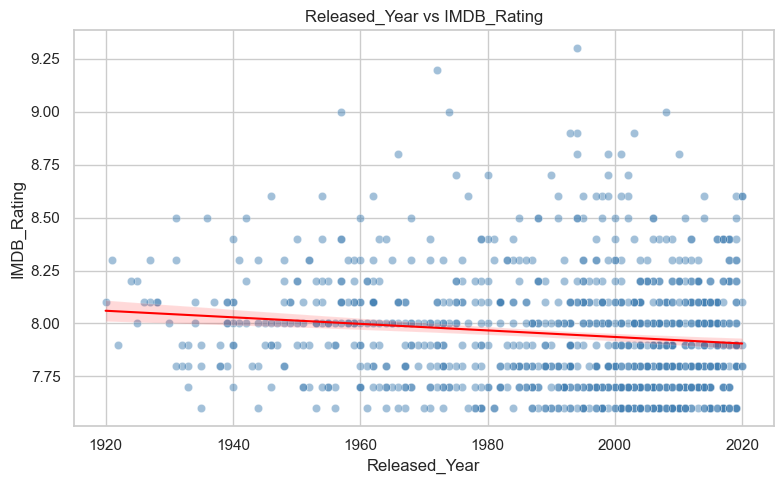

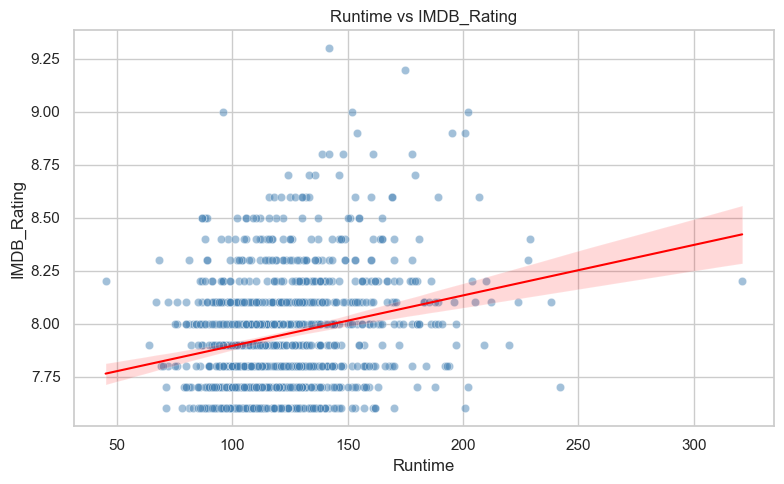

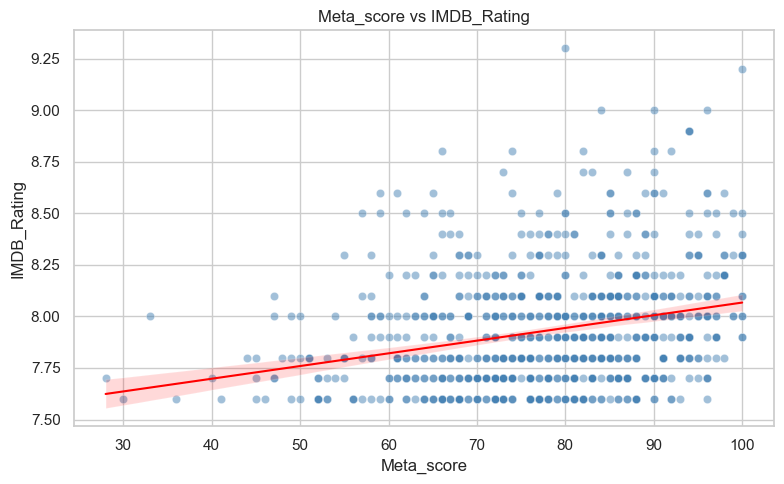

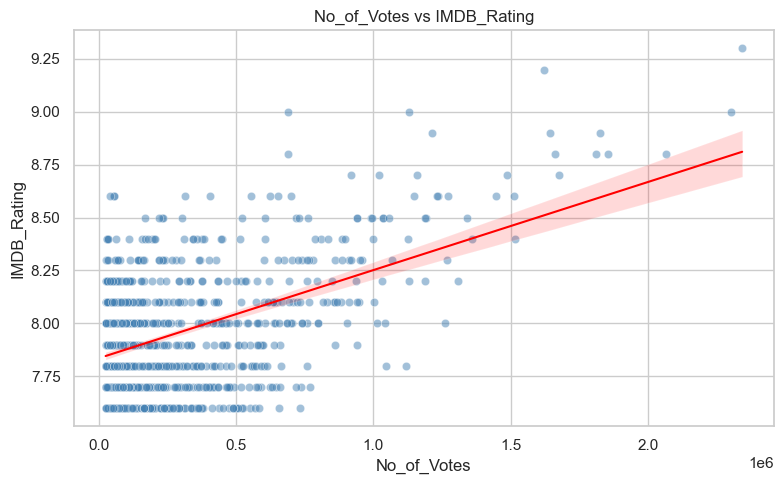

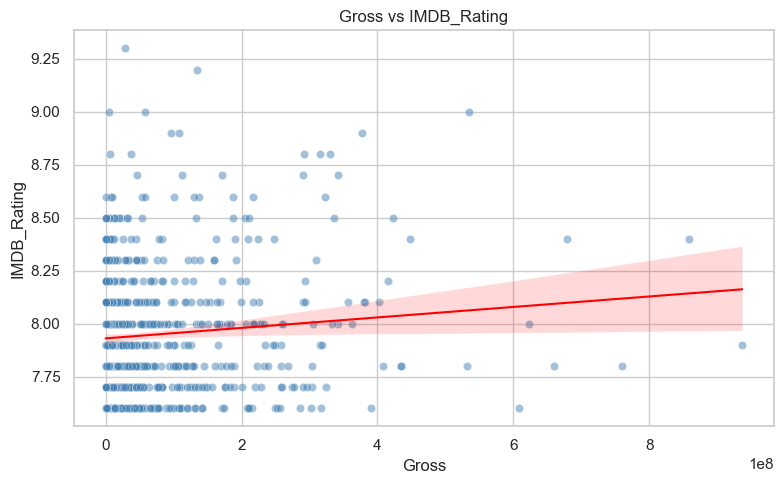

In [21]:
numeric_cols
# Step 13: Scatter plots of numeric features vs IMDB_Rating
numeric_features = [col for col in numeric_cols if col != 'IMDB_Rating']

for col in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df_clean[col], y=df_clean['IMDB_Rating'], alpha=0.5, color='steelblue')
    sns.regplot(x=df_clean[col], y=df_clean['IMDB_Rating'],
                scatter=False, color='red', line_kws={'linewidth': 1.5})
    plt.title(f'{col} vs IMDB_Rating')
    plt.xlabel(col)
    plt.ylabel('IMDB_Rating')
    plt.tight_layout()
    plt.show()

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\3638170121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='IMDB_Rating', data=subset, order=order, palette='Blues')


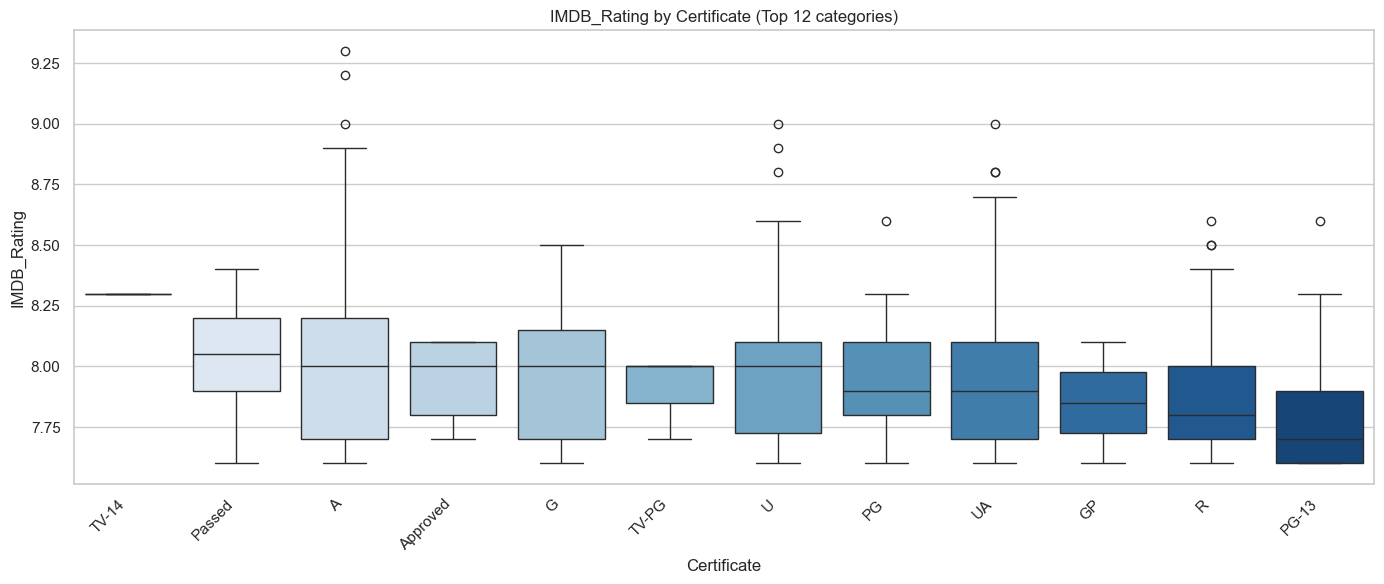

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\3638170121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='IMDB_Rating', data=subset, order=order, palette='Blues')


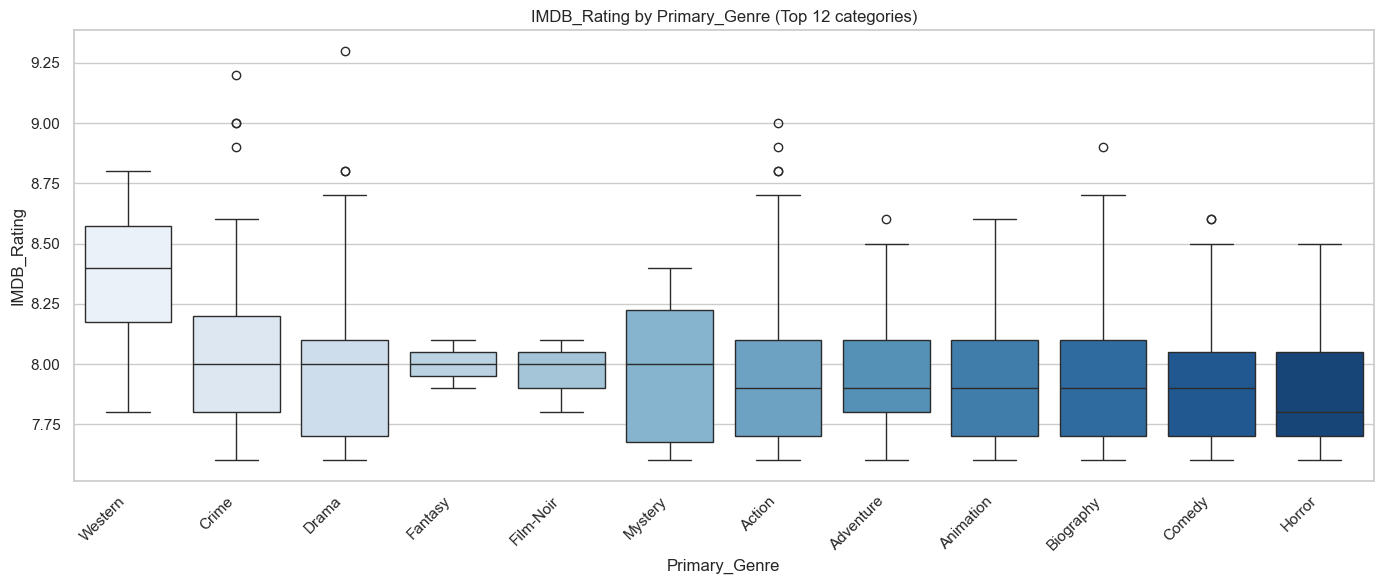

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\3638170121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='IMDB_Rating', data=subset, order=order, palette='Blues')


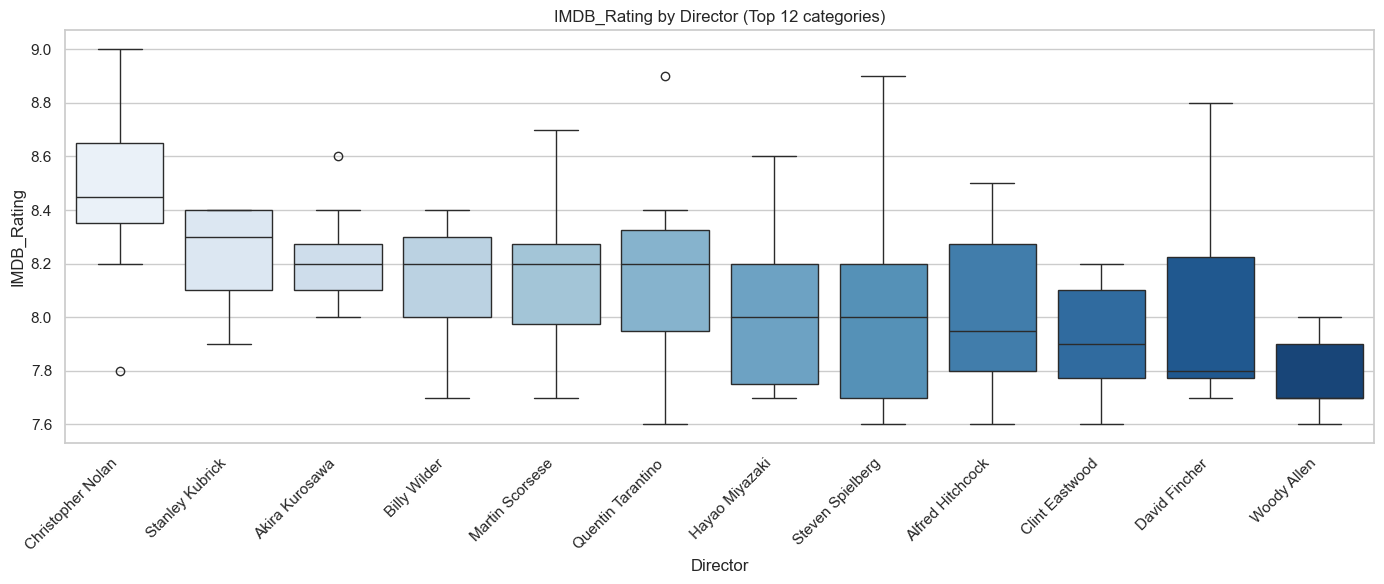

C:\Users\Meenal\AppData\Local\Temp\ipykernel_31980\3638170121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='IMDB_Rating', data=subset, order=order, palette='Blues')


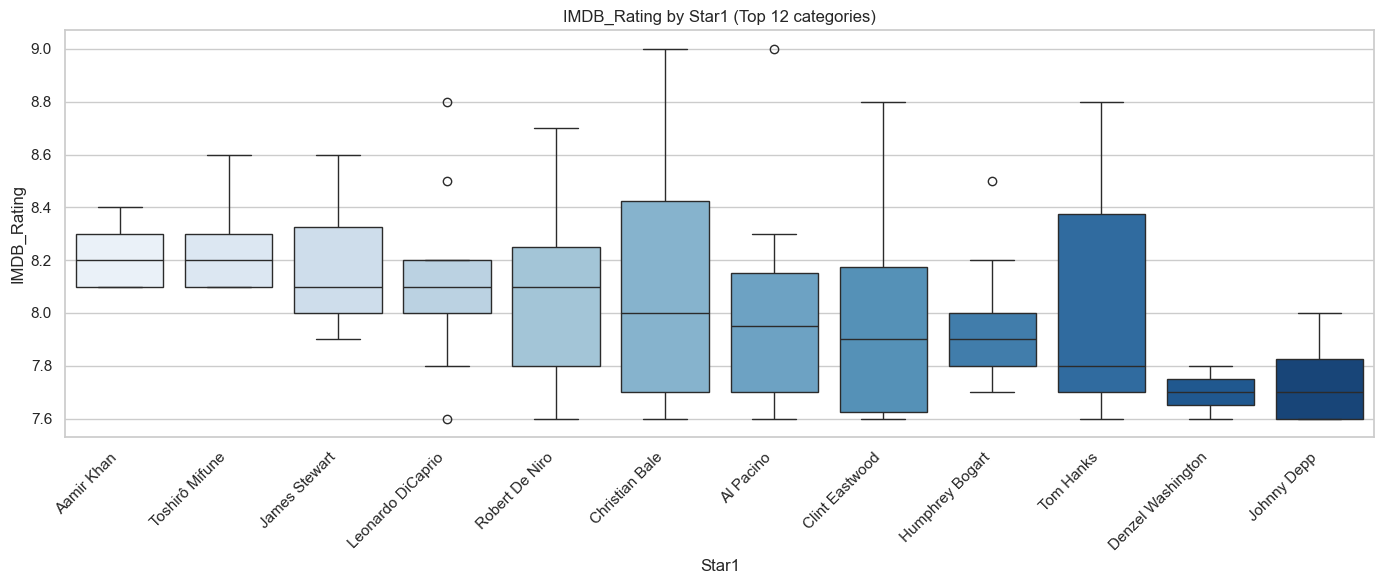

In [22]:
categorical_cols
# Step 14: Boxplots of IMDB_Rating by categorical feature
key_cats = ['Certificate', 'Primary_Genre', 'Director', 'Star1']

for col in key_cats:
    top_cats = df_clean[col].value_counts().head(12).index
    subset = df_clean[df_clean[col].isin(top_cats)]
    order = subset.groupby(col)['IMDB_Rating'].median().sort_values(ascending=False).index

    plt.figure(figsize=(14, 6))
    sns.boxplot(x=col, y='IMDB_Rating', data=subset, order=order, palette='Blues')
    plt.title(f'IMDB_Rating by {col} (Top 12 categories)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


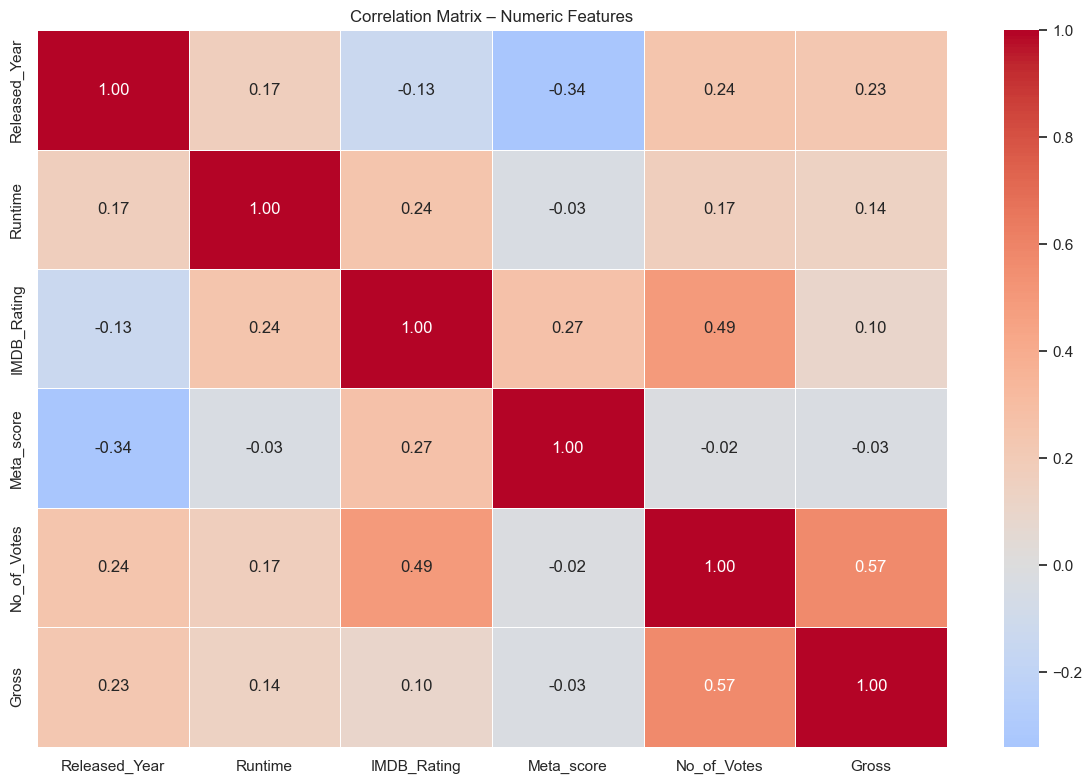

In [23]:
# Step 15: Correlation matrix
plt.figure(figsize=(12, 8))
corr = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm', center=0)
plt.title('Correlation Matrix – Numeric Features')
plt.tight_layout()
plt.show()


In [ ]:
# Step 16: Inspect missing values
print('Missing values before model preprocessing:')
print(df_clean.isnull().sum().sort_values(ascending=False))

# Imputation is performed inside the sklearn pipeline after the train/test split.
# This prevents information from the test set leaking into training.

Missing values before imputation:
Released_Year      1
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
Primary_Genre      0
dtype: int64

  [Numeric]  Filled "Released_Year" with median = 1999.0
  [Numeric]  Filled "Meta_score" with median = 79.0
  [Numeric]  Filled "Gross" with median = 23530892.0
  [Categoric] Filled "Certificate" with mode = U

Missing values after imputation:
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
Primary_Genre    0
dtype: int64


In [ ]:
# Step 17: Build a leakage-safe preprocessing and regression pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df_model = df_clean.drop(columns=['Genre']).copy()
y = df_model.pop('IMDB_Rating')
X = df_model

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', SimpleImputer(strategy='median'), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Model pipeline created successfully.')

Categorical columns to encode: ['Certificate', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'Primary_Genre']

Shape after encoding: (1000, 13)


,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Primary_Genre
0,1994.0,1,142,9.3,80.0,141,599,568,89,912,2343110,28341469.0,6
1,1972.0,1,175,9.2,100.0,137,417,9,336,194,1620367,134966411.0,5
2,2008.0,14,152,9.0,84.0,83,128,283,1,620,2303232,534858444.0,0
3,1974.0,1,202,9.0,90.0,137,9,657,704,194,1129952,57300000.0,5
4,1957.0,12,96,9.0,96.0,456,252,464,535,421,689845,4360000.0,5


In [ ]:
# Step 18: Split before fitting any preprocessing steps
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train statistics:')
print(y_train.describe())

X_train shape: (800, 12)
X_test shape:  (200, 12)

y_train statistics:
count    800.000000
mean       7.952625
std        0.280698
min        7.600000
25%        7.700000
50%        7.900000
75%        8.100000
max        9.300000
Name: IMDB_Rating, dtype: float64


In [ ]:
# Step 19: Train and evaluate the model
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

results = pd.DataFrame({
    'Model': ['Mean baseline', 'Random forest'],
    'MAE': [
        mean_absolute_error(y_test, baseline_predictions),
        mean_absolute_error(y_test, predictions)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, baseline_predictions)),
        np.sqrt(mean_squared_error(y_test, predictions))
    ],
    'R2': [
        r2_score(y_test, baseline_predictions),
        r2_score(y_test, predictions)
    ]
})

results

Scaling complete.
X_train_scaled shape: (800, 12)
X_test_scaled shape:  (200, 12)

Sample scaled values (first row of X_train_scaled):
[-0.61313097  1.12493342 -0.08660644  1.05702523 -0.6582305   0.4502192
 -0.57441244 -1.32406087 -1.65015376  2.84952979  2.69460324 -1.45194517]
